In [1]:
#important libraries 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [2]:
file_path = r"D:\BPS\dataset\IoT\iot_benign_ddos_reduced.csv"
#define target
target = "traffic_class"

In [3]:
df = pd.read_csv(file_path) 

In [4]:
print(df[target].value_counts())

traffic_class
ddos      3491386
benign     398330
Name: count, dtype: int64


In [6]:
#separatetarget and features 
X = df.drop(columns=[target])
y = df[target]

In [7]:
#ensure target is "ddos"
y = y.astype(str).str.strip().str.lower()

In [8]:
# keep only numeric columns
X = X.select_dtypes(include=[np.number])

In [10]:
# check if inf from flow byte's and floe packet's were removed previously. it was less than 0.05%
print(np.isinf(X).any().any())
print(np.isneginf(X).any().any())

True
False


In [11]:
# Remove the rows already ifentified in the EDA process. 
mask = np.isfinite(X).all(axis=1)

X = X[mask]
y = y[mask]

print("New shape:", X.shape)

New shape: (3887657, 19)


In [12]:
# Train-test split - 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3110125, 19)
Test: (777532, 19)


In [20]:
# train model
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    max_leaf_nodes=1000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_leaf_nodes=1000, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [21]:
# predictions
y_pred = model.predict(X_test)

In [22]:
# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="ddos")
recall = recall_score(y_test, y_pred, pos_label="ddos")
f1 = f1_score(y_test, y_pred, pos_label="ddos")

print("\nRandom Forest Results")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Random Forest Results
Accuracy: 0.945356589825242
Precision: 0.9529912816777
Recall: 0.9878491227869068
F1-score: 0.9701071756990554

Classification Report:

              precision    recall  f1-score   support

      benign       0.84      0.57      0.68     79640
        ddos       0.95      0.99      0.97    697892

    accuracy                           0.95    777532
   macro avg       0.90      0.78      0.83    777532
weighted avg       0.94      0.95      0.94    777532


Confusion Matrix:

[[ 45633  34007]
 [  8480 689412]]


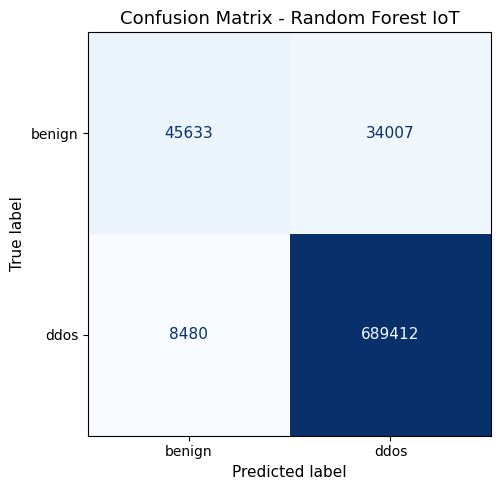

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["benign", "ddos"],
    cmap="Blues",
    ax=ax,
    colorbar=False  
)

# fix num. size 
for text in disp.text_.ravel():
    text.set_fontsize(11)

ax.set_title("Confusion Matrix - Random Forest IoT", fontsize=13)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
plt.tight_layout()
plt.savefig("Confusion Matrix - Random Forest IoT", dpi=300, bbox_inches="tight")
plt.show()